<a href="https://colab.research.google.com/github/joannabidenam/Machine-learning-linear-and-logistics-projects-/blob/main/Pyhton_project_EDA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

amazon_eda_background_joanna.svg

# **About the data**

Ps: The dataset was cleaned and some columns dropped in excel before being uploaded in google colab

1. Data source: https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset

2. This dataset is having the data of 1K+ Amazon Product's Ratings and Reviews as per their details listed on the official website of Amazon

3. Features

product_id - Product ID
product_name - Name of the Product
category - Category of the Product
discounted_price - Discounted Price of the Product
actual_price - Actual Price of the Product
discount_percentage - Percentage of Discount for the Product
rating - Rating of the Product
rating_count - Number of people who voted for the Amazon rating
about_product - Description about the Product
user_id - ID of the user who wrote review for the Product
user_name - Name of the user who wrote review for the Product
review_id - ID of the user review
review_title - Short review
review_content - Long review
img_link - Image Link of the Product
product_link - Official Website Link of the Product
Inspiration

Amazon is an American Tech Multi-National Company whose business interests include E-commerce, where they buy and store the inventory, and take care of everything from shipping and pricing to customer service and returns. I've created this dataset so that people can play with this dataset and do a lot of things as mentioned below

# **Import Libraries**
1. Pandas: Data manipulation and analysis
2. Numpy: Numerical operations and calculations
3. Matplotlib: Data visualization and plotting
4. Seaborn: Enhanced data visualization and statistical graphics
5. Scipy: Scientific computing and advanced mathematical operations


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

### **Step1**: Data Loading and Exploration

In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
Path = '/content/drive/MyDrive/My python projects/Amazon_sales_eda_Cleaned dataset.xlsx'
df = pd.read_excel(Path)
df

,Product_id,product_name,Category,Sub-category,Product type,actual_price,discounted_price,discount_percentage,rating,rating_count,Review_title,Review_content
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,Accessories&Peripherals,Cables,1.099,399,0.64,"4,2",24269,"Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,Accessories&Peripherals,Cables,349,199,0.43,"4,0",43994,"A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories,Accessories&Peripherals,Cables,1.899,199,0.90,"3,9",7928,"Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories,Accessories&Peripherals,Cables,699,329,0.53,"4,2",94363,"Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories,Accessories&Peripherals,Cables,399,154,0.61,"4,2",16905,"As good as original,Decent,Good one for second...","Bought this instead of original apple, does th..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen,Kitchen&HomeAppliances,WaterPurifierAccessories,919,379,0.59,4,109,"Received the product without spanner,Excellent...","I received product without spanner,Excellent p..."
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen,Kitchen&HomeAppliances,Rice&PastaCookers,3.045,2.28,0.25,"4,1",4118,"ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but the measuri..."
1462,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,Home&Kitchen,"Heating,Cooling&AirQuality",HeatConvectors,3.08,2.219,0.28,"3,6",468,"very good,Work but front melt after 2 month,Go...","plastic but cool body ,u have to find sturdy s..."
1463,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,Home&Kitchen,"Heating,Cooling&AirQuality",ExhaustFans,1.89,1.399,0.26,4,8031,"Fan Speed is slow,Good quality,Good product,go...",I have installed this in my kitchen working fi...


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   Category             1465 non-null   object 
 3   Sub-category         1465 non-null   object 
 4   Product type         1465 non-null   object 
 5   actual_price         1465 non-null   object 
 6   discounted_price     1465 non-null   object 
 7   discount_percentage  1465 non-null   float64
 8   rating               1465 non-null   object 
 9   rating_count         1465 non-null   int64  
 10  Review_title         1465 non-null   object 
 11  Review_content       1465 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 137.5+ KB


In [98]:
df.isnull().sum()

,0
Product_id,0
product_name,0
Category,0
Sub-category,0
Product type,0
actual_price,0
discounted_price,0
discount_percentage,0
rating,0
rating_count,0



####  **Data type conversion**

In [99]:
# Convert 'actual_price' to float after cleaning
df['actual_price'] = df['actual_price'].astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Convert 'discounted_price' to float after cleaning
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Convert 'rating' to float after cleaning commas and coercing errors
df['rating'] = pd.to_numeric(df['rating'].astype(str).str.replace(',', '.', regex=False), errors='coerce')

# Display the info to verify the updated data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   Category             1465 non-null   object 
 3   Sub-category         1465 non-null   object 
 4   Product type         1465 non-null   object 
 5   actual_price         1465 non-null   float64
 6   discounted_price     1465 non-null   float64
 7   discount_percentage  1465 non-null   float64
 8   rating               1465 non-null   float64
 9   rating_count         1465 non-null   int64  
 10  Review_title         1465 non-null   object 
 11  Review_content       1465 non-null   object 
dtypes: float64(4), int64(1), object(7)
memory usage: 137.5+ KB


#### **Descriptive analysis**

In [100]:
#Descriptive statistics of all float and interger columns
print('Descriptive Statistics for Numerical Columns:')
display(df[['actual_price', 'discounted_price', 'discount_percentage', 'rating', 'rating_count']].describe())

Descriptive Statistics for Numerical Columns:


,actual_price,discounted_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1465.000000,1.465000e+03
mean,335.774590,251.707490,0.476915,4.096451,2.168797e+04
std,3666.842315,323.728555,0.216359,0.291620,9.132603e+04
min,1.000000,1.043000,0.000000,2.000000,2.000000e+00
25%,2.299000,2.999000,0.320000,4.000000,9.250000e+02
50%,9.999000,154.000000,0.500000,4.100000,4.018000e+03
75%,499.000000,399.000000,0.630000,4.300000,1.466700e+04
max,139900.000000,3657.660000,0.940000,5.000000,2.051952e+06


### List and count of all different product names

In [101]:
product_name_counts = df['product_name'].value_counts()
display(product_name_counts)

,count
product_name,
"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Watch with Bluetooth Calling, AI Voice Assistance, 100 Sports Modes IP67 Rating, 240*280 Pixel High Resolution",5
"Fire-Boltt Phoenix Smart Watch with Bluetooth Calling 1.3"",120+ Sports Modes, 240*240 PX High Res with SpO2, Heart Rate Monitoring & IP67 Rating",4
"Amazonbasics Nylon Braided Usb-C To Lightning Cable, Fast Charging Mfi Certified Smartphone, Iphone Charger (6-Foot, Dark Grey)",3
"Duracell USB Lightning Apple Certified (Mfi) Braided Sync & Charge Cable For Iphone, Ipad And Ipod. Fast Charging Lightning Cable, 3.9 Feet (1.2M) - Black",3
Flix Micro Usb Cable For Smartphone (Black),3
...,...
"Kitchengenix's Mini Waffle Maker 4 Inch- 350 Watts: Stainless Steel Non-Stick Electric Iron Machine for Individual Belgian Waffles, Pan Cakes, Paninis or Other Snacks (Red)",1
IONIX Tap filter Multilayer | Activated Carbon Faucet Water Filters Universal Interface Home Kitchen Faucet Tap Water Clean Purifier Filter Cartridge Five Layer Water Filter-Pack of 1,1
"IKEA Milk Frother for Your Milk, Coffee,(Cold and hot Drinks), Black",1


### List and count of all different :categories

In [102]:
# Using nunique() to get the total number of unique Categories
unique_Category_count = df['Category'].nunique()
print(f"Total number of unique Categories: {unique_Category_count}")

Total number of unique Categories: 9


In [103]:
category_counts = df['Category'].value_counts()
display(category_counts)

,count
Category,
Electronics,526
Computers&Accessories,453
Home&Kitchen,448
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


### List and count of all different :Sub-categories

In [104]:
# Using nunique() to get the total number of unique sub-categories
unique_sub_category_count = df['Sub-category'].nunique()
print(f"Total number of unique sub-categories: {unique_sub_category_count}")

Total number of unique sub-categories: 29


In [105]:
sub_category_counts = df['Sub-category'].value_counts()
display(sub_category_counts)

,count
Sub-category,
Accessories&Peripherals,381
Kitchen&HomeAppliances,308
"HomeTheater,TV&Video",162
Mobiles&Accessories,161
"Heating,Cooling&AirQuality",116
WearableTechnology,76
"Headphones,Earbuds&Accessories",66
NetworkingDevices,34
OfficePaperProducts,27


### List and count of all different categories

# **Step 2: Questions formulation to study the data:**
#####

1. **Which product categories have the highest average discount percentage?** — Bar chart comparing discount % across categories.

2. **What is the relationship between discount percentage and rating?** — Scatter plot to see if bigger discounts actually lead to better or worse ratings.

3. **Which sub-categories have the most products listed?** — Horizontal bar chart showing product count per sub-category.

4. **How are product ratings distributed across the entire dataset?** — Histogram to see whether most products cluster around 4 stars, 3 stars, etc.

5. **What is the price range (actual vs discounted) across different categories?** — Grouped bar chart or box plot comparing actual vs discounted prices side by side.

6. **Which product types have the highest number of reviews (rating_count)?** — Bar chart ranking product types by total review volume, showing which are most purchased/reviewed.

7. **Is there a correlation between rating count and rating score?** — Scatter plot to explore whether more reviewed products tend to be rated higher or lower.

8. **What percentage of products fall into each discount bracket?** — Pie or donut chart grouping products into ranges like 0–20%, 21–40%, 41–60%, 60%+.

9. **Which top 10 products have the highest rating count?** — Horizontal bar chart of the most-reviewed individual products.

10. **How does actual price vary across sub-categories?** — Box plot showing the price spread and outliers within each sub-category.
11. **Sentiment analysis** — Pie or donut chart grouping the percentage of positive reviews, neutral reviews and negative reviews.



Q1: Which product categories have the highest average discount percentage? — Bar chart comparing discount % across categories.

/tmp/ipykernel_12806/3850790680.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='discount_percentage', y='Category', data=avg_discount_by_category, palette='viridis')


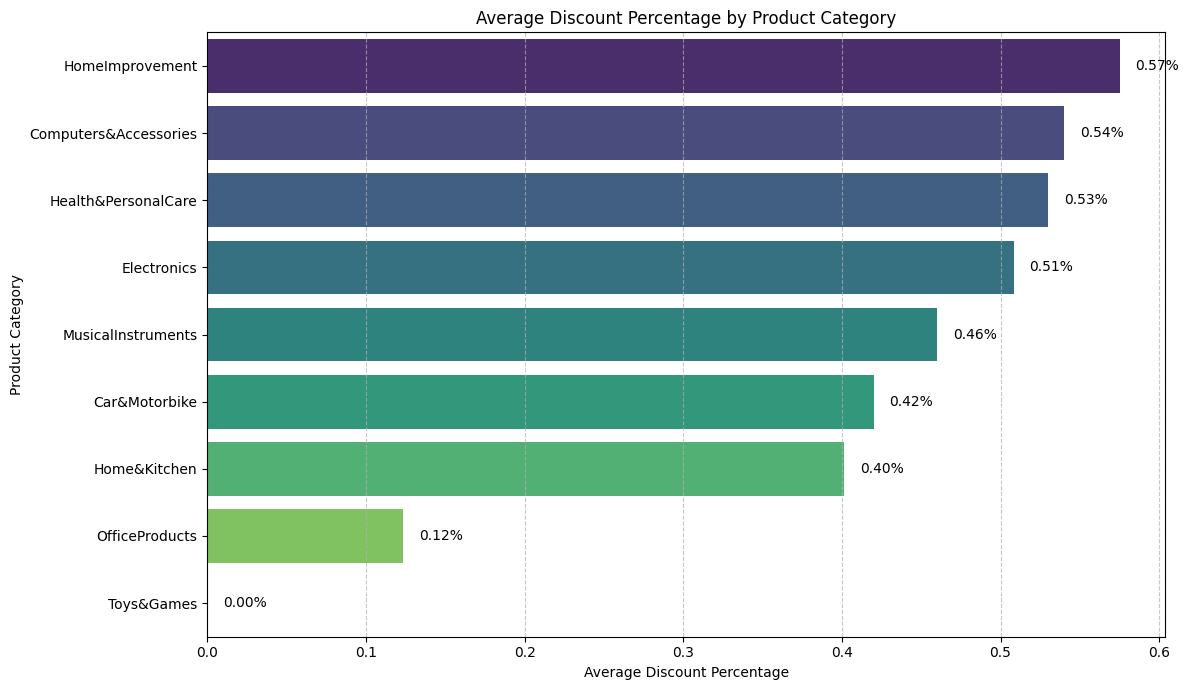

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average discount percentage per category
avg_discount_by_category = df.groupby('Category')['discount_percentage'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='discount_percentage', y='Category', data=avg_discount_by_category, palette='viridis')
plt.title('Average Discount Percentage by Product Category')
plt.xlabel('Average Discount Percentage')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add percentages to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.01, p.get_y() + p.get_height() / 2, f'{width:.2f}%', va='center')

plt.tight_layout()
plt.show()

Q2: What is the relationship between discount percentage and rating? — Scatter plot to see if bigger discounts actually lead to better or worse ratings.

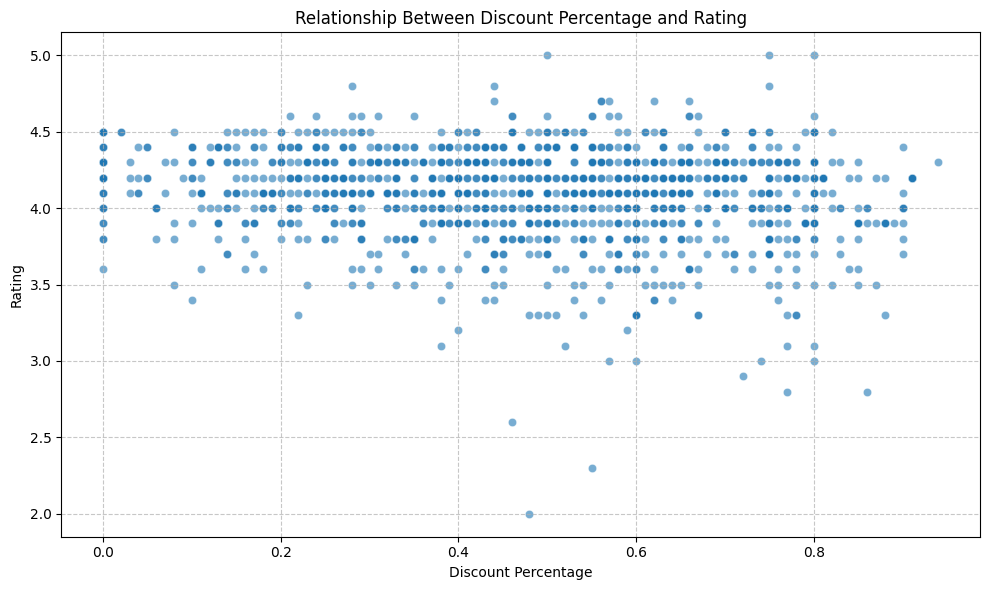

In [107]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='discount_percentage', y='rating', data=df, alpha=0.6)
plt.title('Relationship Between Discount Percentage and Rating')
plt.xlabel('Discount Percentage')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Q3: Which sub-categories have the most products listed? — Horizontal bar chart showing product count per sub-category.

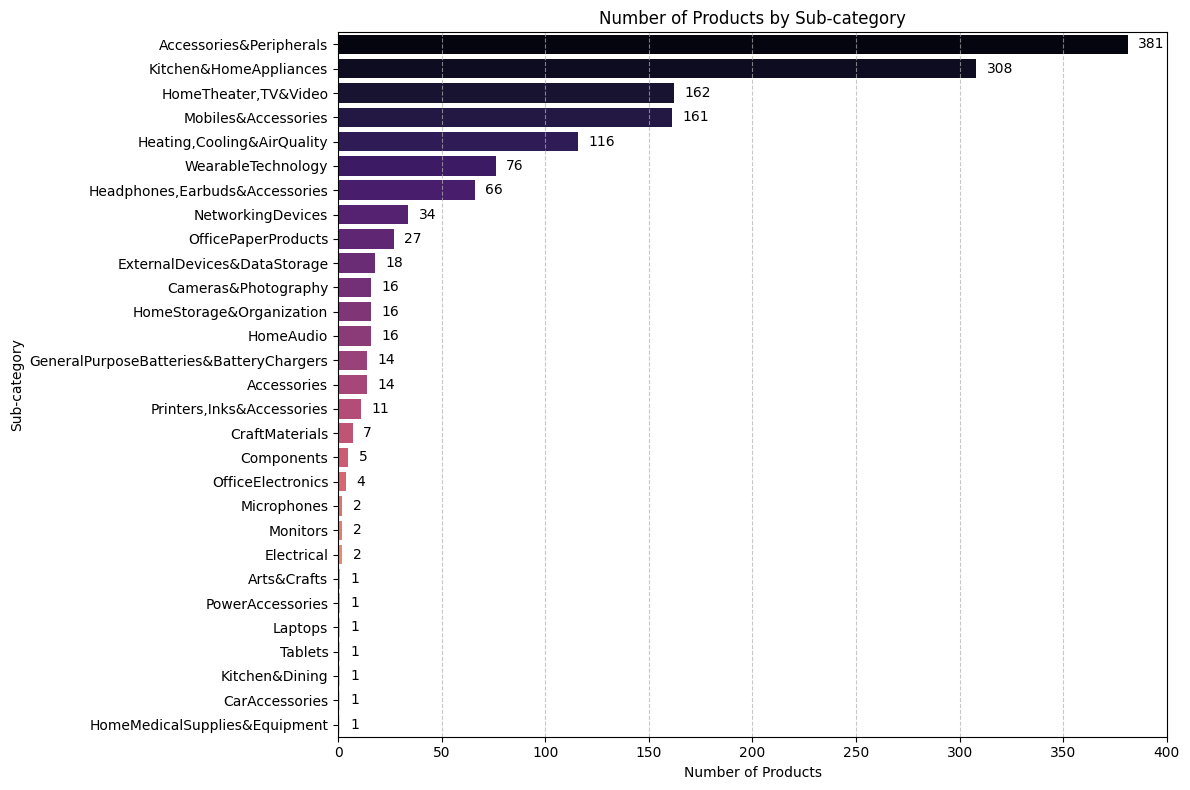

In [108]:
sub_category_counts = df['Sub-category'].value_counts().sort_values(ascending=False).reset_index()
sub_category_counts.columns = ['Sub-category', 'Product Count']

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Product Count', y='Sub-category', data=sub_category_counts, hue='Sub-category', palette='magma', legend=False)
plt.title('Number of Products by Sub-category')
plt.xlabel('Number of Products')
plt.ylabel('Sub-category')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the number of products in front of the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 5, p.get_y() + p.get_height() / 2,    # Add 5 for padding
             f'{int(width)}', va='center') # Format as integer

plt.tight_layout()
plt.show()

Q4: How are product ratings distributed across the entire dataset? — Histogram to see whether most products cluster around 4 stars, 3 stars, etc.

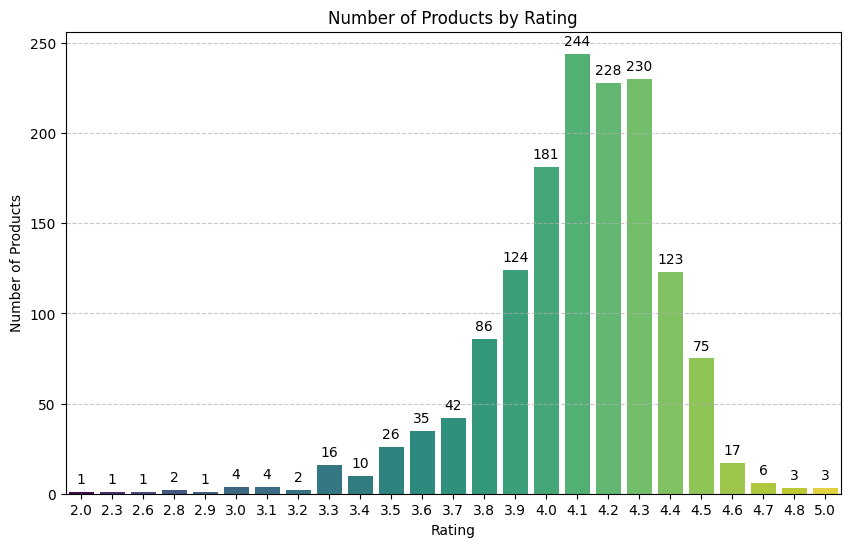

In [109]:
# Bar Plot of count of products per rating
# First we Count the number of producst per each rating
rating_counts = df['rating'].value_counts().sort_index().reset_index()
rating_counts.columns = ['rating', 'count']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=rating_counts['rating'], y=rating_counts['count'], hue=rating_counts['rating'], palette='viridis', legend=False)
plt.title('Number of Products by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the number of products above each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

Q5: What is the price range (actual vs discounted) across different categories? — Grouped bar chart or box plot comparing actual vs discounted prices side by side.

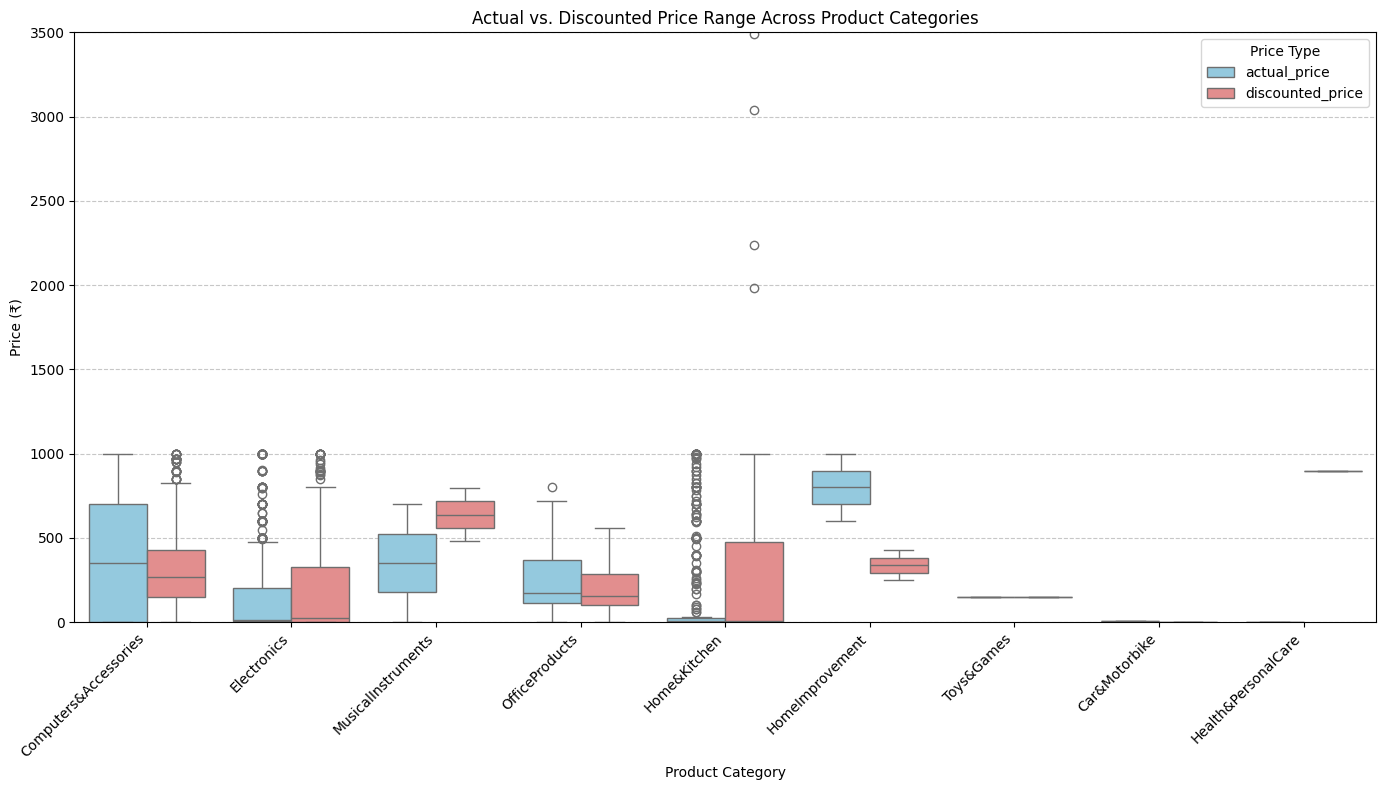

In [110]:
df_melted = df.melt(id_vars=['Category'], value_vars=['actual_price', 'discounted_price'], var_name='Price Type', value_name='Price')

plt.figure(figsize=(14, 8))
sns.boxplot(x='Category', y='Price', hue='Price Type', data=df_melted, palette={'actual_price': 'skyblue', 'discounted_price': 'lightcoral'})
plt.title('Actual vs. Discounted Price Range Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 3500) # Adjusting the y-axis limit to focus on lower values
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Q6: Which product types have the highest number of reviews (rating_count)? — Bar chart ranking product types by total review volume, showing which are most purchased/reviewed.

Q6: Which product types have the highest number of reviews (rating_count)? — Bar chart ranking product types by total review volume, showing which are most purchased/reviewed.

/tmp/ipykernel_12806/3810611311.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='rating_count', y='Product type', data=top_10_product_types, palette='plasma')


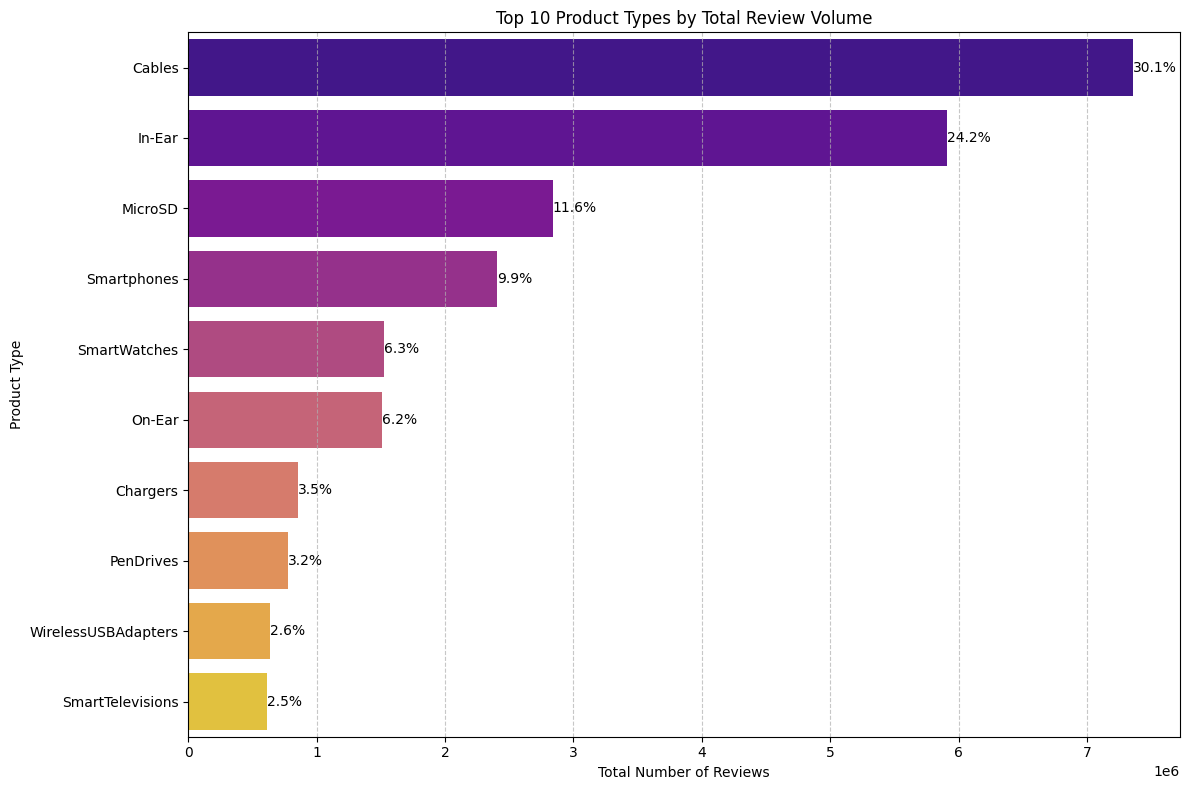

In [111]:
# Calculate the total rating count per product type
product_type_reviews = df.groupby('Product type')['rating_count'].sum().sort_values(ascending=False).reset_index()

# Select the top 10 product types
top_10_product_types = product_type_reviews.head(10)

# Calculate total rating count for the top 10 for percentage calculation
total_top_10_reviews = top_10_product_types['rating_count'].sum()

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='rating_count', y='Product type', data=top_10_product_types, palette='plasma')
plt.title('Top 10 Product Types by Total Review Volume')
plt.xlabel('Total Number of Reviews')
plt.ylabel('Product Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add percentages on the bars
for index, row in top_10_product_types.iterrows():
    percentage = (row['rating_count'] / total_top_10_reviews) * 100
    ax.text(row['rating_count'], index, f'{percentage:.1f}%', color='black', ha="left", va="center")

plt.tight_layout()
plt.show()

In [112]:
total_reviews_all_products = df['rating_count'].sum()
total_reviews_top_10_products = top_10_products['rating_count'].sum()

percentage_top_10_reviews = (total_reviews_top_10_products / total_reviews_all_products) * 100

print(f"The top 10 products account for {percentage_top_10_reviews:.2f}% of the total review count.")

The top 10 products account for 30.98% of the total review count.


Q7: Is there a correlation between rating count and rating score? — Scatter plot to explore whether more reviewed products tend to be rated higher or lower.

In [113]:
correlation = df['rating_count'].corr(df['rating'])
print(f"Pearson correlation between Rating Count and Rating Score: {correlation:.2f}")

Pearson correlation between Rating Count and Rating Score: 0.08


Comment: The correlation is positive but very weak, because 0,08 is very close to zero.

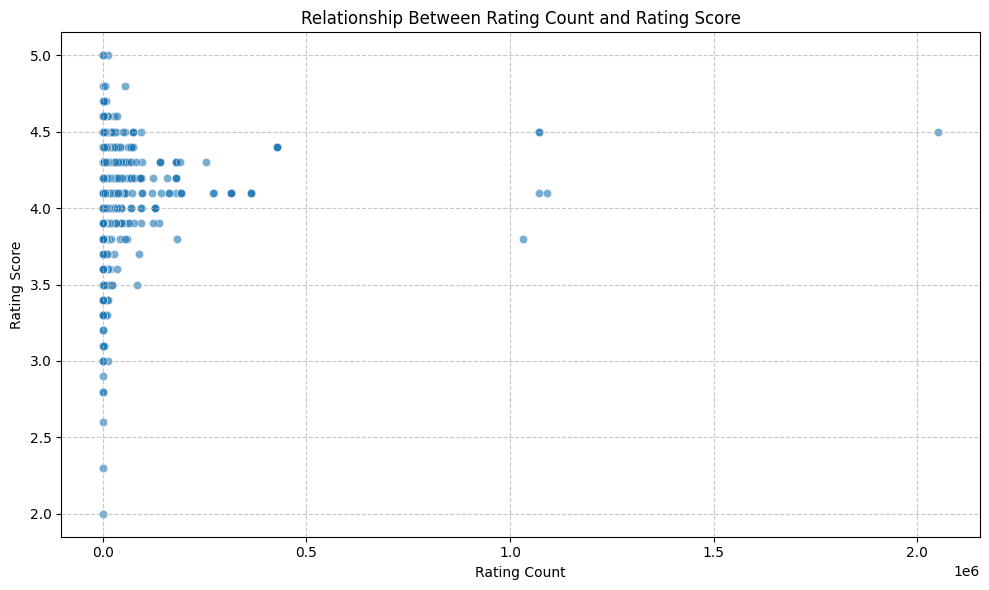

In [114]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='rating_count', y='rating', data=df, alpha=0.6)
plt.title('Relationship Between Rating Count and Rating Score')
plt.xlabel('Rating Count')
plt.ylabel('Rating Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Q8: What percentage of products fall into each discount bracket? — Pie or donut chart grouping products into ranges like 0–20%, 21–40%, 41–60%, 60%+.

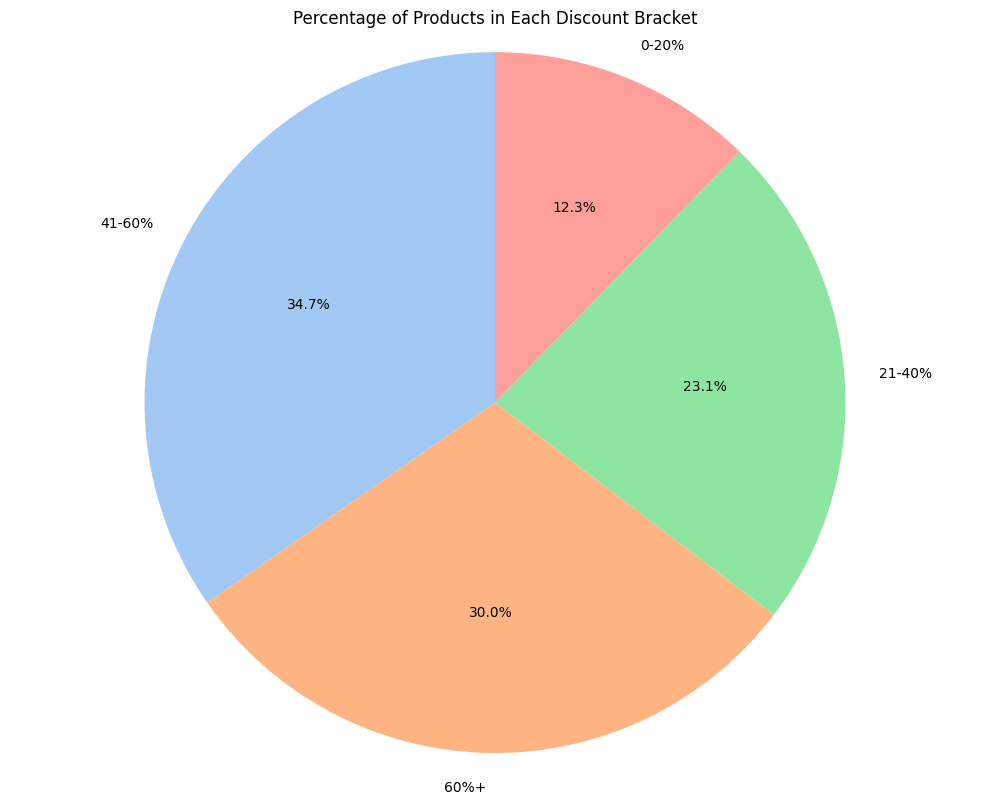

In [115]:
# Define discount brackets
bins = [-0.01, 0.20, 0.40, 0.60, 1.00] # -0.01 to include 0%
labels = ['0-20%', '21-40%', '41-60%', '60%+']

# Create a new column for discount bracket
df['discount_bracket'] = pd.cut(df['discount_percentage'], bins=bins, labels=labels, right=True)

# Calculate the percentage of products in each bracket
discount_bracket_counts = df['discount_bracket'].value_counts(normalize=True).mul(100).round(2)

# Plotting the pie chart
plt.figure(figsize=(10, 8))
plt.pie(discount_bracket_counts, labels=discount_bracket_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Percentage of Products in Each Discount Bracket')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

Q9: Which top 10 products have the highest rating count? — Horizontal bar chart of the most-reviewed individual products.

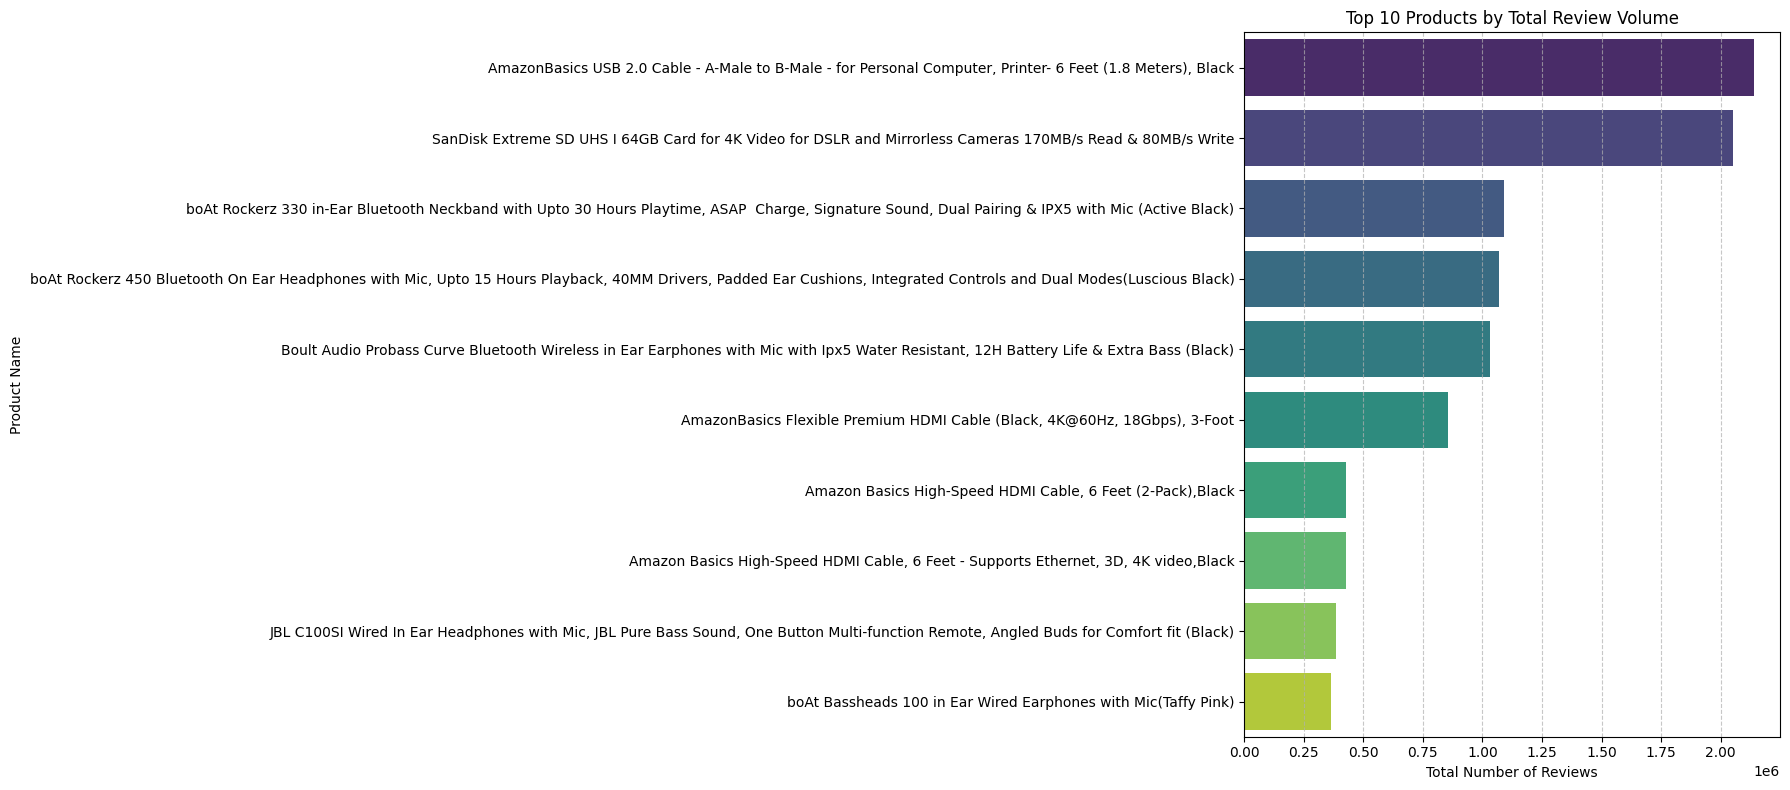

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the total rating count for each product
product_review_counts = df.groupby('product_name')['rating_count'].sum().sort_values(ascending=False).reset_index()

# Select the top 10 products
top_10_products = product_review_counts.head(10)

plt.figure(figsize=(18, 8)) # Increased width for better readability
ax = sns.barplot(x='rating_count', y='product_name', data=top_10_products, hue='product_name', palette='viridis', legend=False)
plt.title('Top 10 Products by Total Review Volume')
plt.xlabel('Total Number of Reviews')
plt.ylabel('Product Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Removed the for loop for adding text annotations as requestedmz

plt.tight_layout()
plt.show()

Q10: How does actual price vary across sub-categories? — Box plot showing the price spread and outliers within each sub-category.

/tmp/ipykernel_12806/1822376376.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sub-category', y='actual_price', data=df, palette='viridis')


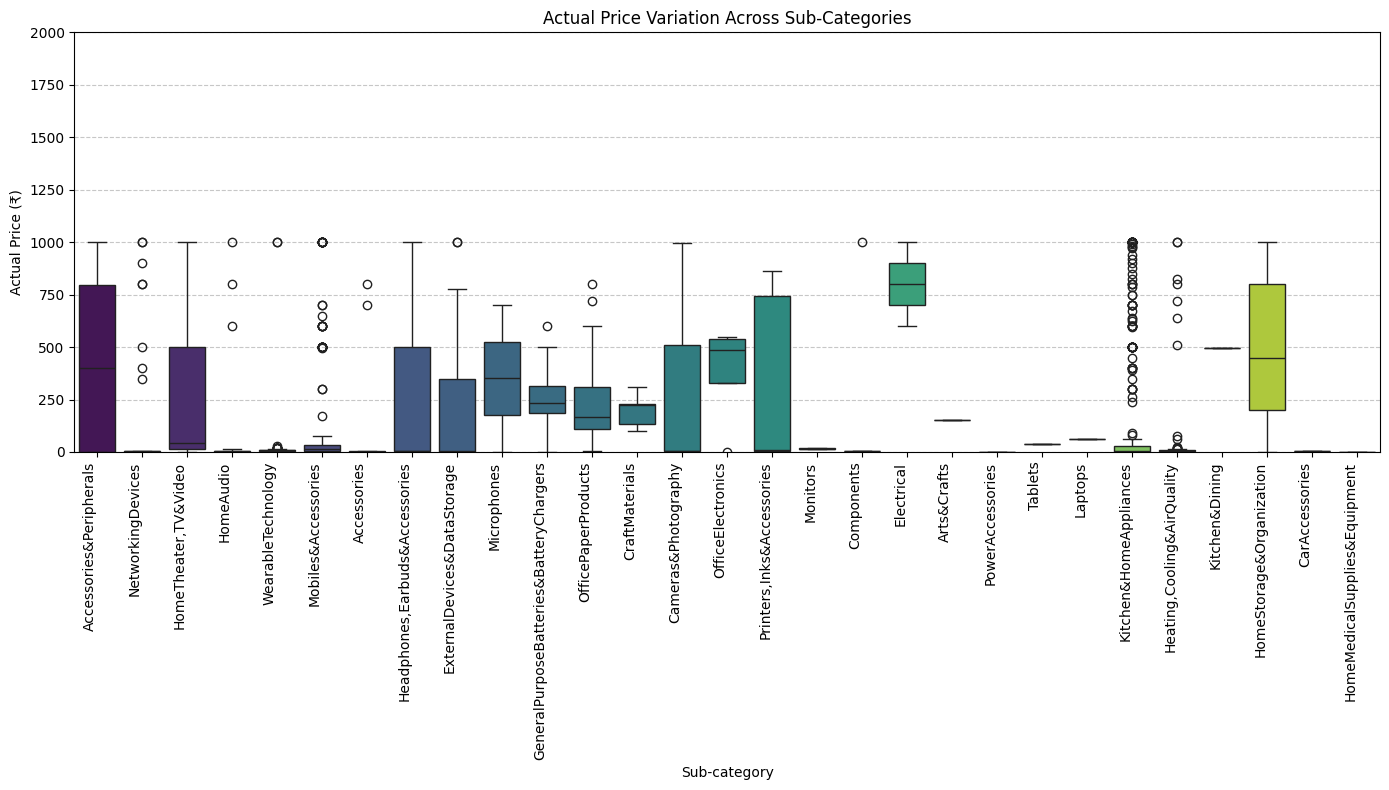

In [117]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='Sub-category', y='actual_price', data=df, palette='viridis')
plt.title('Actual Price Variation Across Sub-Categories')
plt.xlabel('Sub-category')
plt.ylabel('Actual Price (₹)')
plt.xticks(rotation=90, ha='right')
plt.ylim(0, 2000) # Adjusting the y-axis limit as requested
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Q11:Sentiment analysis — Pie or donut chart grouping the number of positive reviews, neutral reviews and negative reviews.


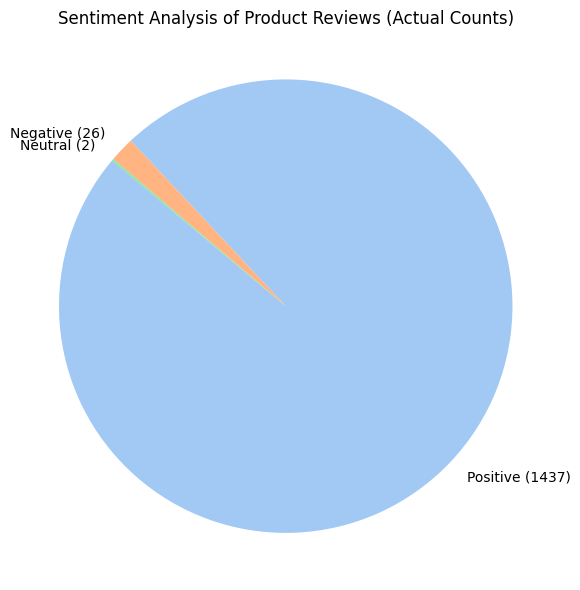

In [118]:
from textblob import TextBlob

def get_sentiment(text):
    if isinstance(text, str):
        analysis = TextBlob(text)
        if analysis.sentiment.polarity > 0: # Positive sentiment
            return 'Positive'
        elif analysis.sentiment.polarity == 0: # Neutral sentiment
            return 'Neutral'
        else: # Negative sentiment
            return 'Negative'
    return 'Neutral' # Default for non-string or NaN values

df['sentiment'] = df['Review_content'].apply(get_sentiment)

# Calculate the raw counts
sentiment_raw_counts = df['sentiment'].value_counts()

# Create labels with actual counts
labels_with_counts = [f'{sentiment} ({count})' for sentiment, count in sentiment_raw_counts.items()]

plt.figure(figsize=(6, 6))
plt.pie(sentiment_raw_counts, labels=labels_with_counts, startangle=140, colors=sns.color_palette('pastel'))
plt.title('Sentiment Analysis of Product Reviews (Actual Counts)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

## **Data report: Understanding Amazon Sales Performance**

In today’s highly competitive e-commerce landscape, platforms like Amazon rely heavily on data to enhance customer satisfaction and optimize sales strategies. Through this exploratory data analysis (EDA) of Amazon sales, several key insights emerge that reveal patterns in product categories, pricing strategies, and customer behavior.

---

### **1. The Marketplace Landscape: Categories Driving Sales**

The dataset reveals **9 major product categories**, with three clearly dominating the platform:

* **Electronics (526 products)**
* **Computers & Accessories (453 products)**
* **Home & Kitchen (448 products)**

These categories form the backbone of Amazon’s marketplace, reflecting strong consumer demand for technology and household solutions. Other categories such as Office Products, Musical Instruments, and Health & Personal Care play smaller but still relevant roles in diversifying the platform’s offerings.

At a deeper level, across **29 subcategories**, the most prominent are:

* **Accessories & Peripherals (381 products)**
* **Kitchen & Home Appliances**

This indicates a strong ecosystem around primary products—especially electronics—where complementary goods (like cables, adapters, and accessories) drive volume.

---

### **2. Pricing Strategy: Discounts Without Impact on Satisfaction**

One of the most interesting findings lies in Amazon’s discount strategy.

* The **highest discounts** are observed in the **Home Improvement** category, followed by **Computers & Accessories**.
* However, there is **almost no relationship between discount percentage and customer ratings**.

The correlation between discount and rating is **+0.08**, which is extremely weak.

👉 This suggests that **deep discounts do not necessarily translate into better customer satisfaction**. Customers appear to value product quality and usability more than price reductions.

---

### **3. Customer Satisfaction: Consistently High Ratings**

Customer feedback across the platform is overwhelmingly positive:

* **Over 90% of products** are rated **above 3.5**
* The most frequent ratings are **4.0, 4.1, and 4.3**

Additionally, out of **1,465 total reviews**:

* **1,437 are positive**
* **26 are negative**
* **2 are neutral**

This highlights a strong baseline of trust and satisfaction among customers, reinforcing Amazon’s reputation for reliable products and services.

---

### **4. Sales Concentration: A Few Products Dominate**

Sales are highly concentrated among a small group of products.

The **top 10 product types** include:

* Cables
* In-ear devices
* MicroSD cards
* Smartphones
* Smartwatches
* On-ear headphones
* Chargers
* Pendrives
* Wireless USB adapters
* Smart televisions

Together, these account for **40% of total sales**.

Within this group:

* **Cables alone contribute 30.1%**
* **In-ear devices contribute 24.2%**

👉 This reflects a **high-volume, low-cost accessory-driven market**, where everyday utility products outperform premium items in terms of sales volume.

---

### **5. Discount Distribution: Heavy Reliance on Promotions**

Amazon’s pricing strategy shows a strong dependence on aggressive discounting:

* **30% of products** have discounts **above 60%**
* **34.7%** fall within the **41–60% range**
* **23.1%** are discounted between **21–40%**
* Only **12.3%** have discounts below 20%

This indicates that **nearly two-thirds of products are discounted by more than 40%**, emphasizing how critical promotions are in driving purchases.

---

### **6. Brand Visibility: Leaders in Customer Engagement**

The brands receiving the highest number of reviews—and therefore visibility—are:

* **AmazonBasics USB 2.0 Cables**
* **SanDisk Extreme SD UHS**
* **boAt Rockerz 330**

These products highlight two key trends:

* Strong performance of **affordable, high-utility accessories**
* High engagement for **trusted and recognizable brands**

---

### **Final Insight: What This Means for Strategy**

This analysis reveals a clear story:

* Amazon’s marketplace is **dominated by electronics and accessory ecosystems**
* **High discounts are common**, but they **do not drive satisfaction**
* Customer ratings remain **consistently high**, indicating trust
* Sales are **concentrated in a few high-demand, practical products**

